In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
# Load dataset
df = pd.read_csv(r"C:\Users\ATbru\Downloads\CODE\AI_ML_DL\Algo\Datasets\knn.csv") 
print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Weight(x2)  25 non-null     int64 
 1   Height(y2)  25 non-null     int64 
 2   Class       25 non-null     object
dtypes: int64(2), object(1)
memory usage: 732.0+ bytes
None

First 5 rows:
   Weight(x2)  Height(y2)        Class
0          51         167  Underweight
1          66         177       Normal
2          75         169   Overweight
3          69         176       Normal
4          50         173  Underweight

Missing values:
Weight(x2)    0
Height(y2)    0
Class         0
dtype: int64


In [14]:
# Preprocessing
# Handle missing values (fill with mean for numerical, mode for categorical)
df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [18]:
# Encode categorical variables if any
le = LabelEncoder()
for column in df.columns:
    if df[column].dtype == "object":  # Only encode categorical columns
        df[column] = le.fit_transform(df[column])

In [19]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [20]:
# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

In [21]:
# Print results
print("\nKNN Results:")
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


KNN Results:
Accuracy: 0.8000

Confusion Matrix:
[[2 0 0]
 [1 1 0]
 [0 0 1]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.67      1.00      0.80         2
  Overweight       1.00      0.50      0.67         2
 Underweight       1.00      1.00      1.00         1

    accuracy                           0.80         5
   macro avg       0.89      0.83      0.82         5
weighted avg       0.87      0.80      0.79         5



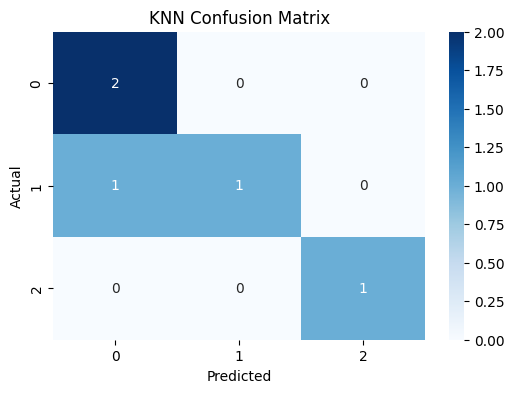

In [22]:
# Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()